In [109]:
from cirq_sic import *
from itertools import combinations

In [72]:
def flatten_if_needed(D):
    return D if D.ndim == 3 else D.reshape(-1, D.shape[-1], D.shape[-1])

def renyi_stabilizer_entropy(rho, D, alpha=2):
    if len(rho.shape) == 1:
        rho = np.outer(rho, rho.conj())
    d = rho.shape[0]
    D = flatten_if_needed(D)
    chi = np.array([abs((a.conj().T @ rho).trace())**2 for a in D])/d
    return (1/(1-alpha))*np.log(np.sum(chi**alpha)) - np.log(d)

def quick_renyi_stabilizer_entropy(rho, D, alpha=2):
    if len(rho.shape) == 1:
        rho = np.outer(rho, rho.conj())
    d = rho.shape[0]
    D = flatten_if_needed(D)
    chi = (np.abs(np.einsum('nij,ij->n', D.conj(), rho, optimize=True))**2)/d
    return (1/(1-alpha))*np.log(np.sum(chi**alpha)) - np.log(d)

def max_renyi_stabilizer_entropy(d, alpha=2):
    return (1/(1-alpha))*np.log((1+(d-1)*(d+1)**(1-alpha))/d)

In [132]:
d = 3
D = wh_operators(d)["D"]

psi0 = np.eye(d)[0]
psi1 = load_sic_fiducial(d)

psi_t = geodesic_interpolator(psi0, psi1)

In [133]:
T = np.linspace(0, 1, 100)
SE = np.array([quick_renyi_stabilizer_entropy(psi_t(t), D) for t in T])

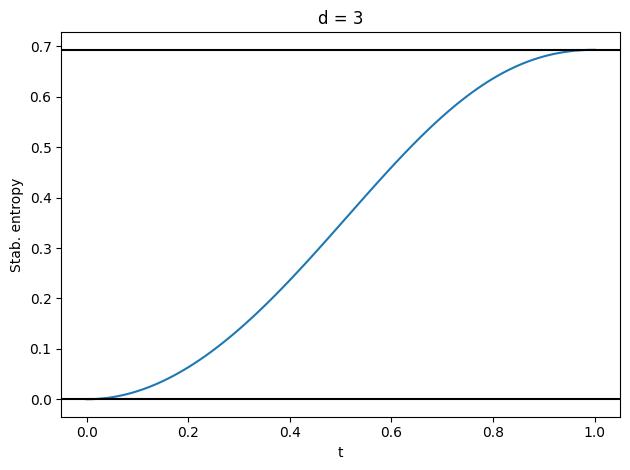

In [134]:
fig, ax = plt.subplots(1, 1)
ax.plot(T, SE)
ax.axhline(y=0, c="black")
ax.axhline(y=max_renyi_stabilizer_entropy(d), c="black")
ax.set_title(f"d = {d}")
ax.set_xlabel("t")
ax.set_ylabel("Stab. entropy")
plt.tight_layout()
plt.show()

In [ ]:
def qudit_wh_operators(d, matrix=True):
    w = np.exp(2 * np.pi * 1j / d)
    tau = -np.exp(1j * np.pi / d)
    Z = np.diag([w ** i for i in range(d)])
    F = np.array([[w**(i*j) for j in range(d)] for i in range(d)])/np.sqrt(d)
    X = F.conj().T @ Z @ F
    D = np.array([[tau**(q*p)*np.linalg.matrix_power(X, q) @ np.linalg.matrix_power(Z, p) for p in range(d)] for q in range(d)])
    return D if matrix else D.reshape(d*d, d, d)

def wh_operators(*dims, matrix=True):
    tensors = [qudit_wh_operators(d, matrix=True) for d in dims]
    sym_dims = [d for d in dims for _ in range(2)]
    all_indices = list(product(*[range(s) for s in sym_dims]))
    total_d = np.prod(dims)
    D = np.zeros(sym_dims + [total_d, total_d], dtype=np.complex128)
    for idx in all_indices:
        ridx = np.array(idx).reshape(-1, 2)
        kron_factor = reduce(np.kron, [tensors[i][tuple(r)] for i, r in enumerate(ridx)])
        D[idx] = kron_factor
    return D if matrix else D.reshape(-1, total_d, total_d)

def symplectic_product(a, b):
    return a[1]*b[0] - a[0]*b[1]

def check_isotropy(S):
    return np.all([symplectic_product(a, b) % d == 0 for b in S for a in S])

In [203]:
d = 4
D = wh_operators(d)
symplectic_indices = list(np.ndindex((d,d)))
lagrangian_subspaces = []
for S in combinations(symplectic_indices[1:], d-1):
    S = [(0,0)] + list(S)
    isotropic = check_isotropy(S)
    if isotropic:
        lagrangian_subspaces.append(S)

Pi = [sum([D[s] for s in S])/d for S in lagrangian_subspaces]
stab = []
for pi in Pi:
    L, V = np.linalg.eigh(pi)
    for i, l in enumerate(L):
        if np.isclose(l, 1):
            stab.append(V[:,i])
stab = np.array(stab)
stab

array([[ 1.   +0.j   ,  0.   +0.j   ,  0.   +0.j   ,  0.   +0.j   ],
       [ 0.5  +0.j   ,  0.5  -0.j   ,  0.5  +0.j   ,  0.5  +0.j   ],
       [ 0.5  +0.j   , -0.354-0.354j, -0.5  +0.j   , -0.354-0.354j],
       [ 0.5  +0.j   ,  0.354-0.354j, -0.5  +0.j   ,  0.354-0.354j]])

In [204]:
np.array([quick_renyi_stabilizer_entropy(s, D) for  s in stab])

array([ 0., -0.,  0., -0.])

In [227]:
import numpy as np
from itertools import combinations, product

# ---- Z_d^2 arithmetic ----
def add(a, b, d): return ((a[0]+b[0]) % d, (a[1]+b[1]) % d)
def smul(t, a, d): return ((t*a[0]) % d, (t*a[1]) % d)

def elt_order(a, d):
    if a == (0,0): return 1
    x = (0,0)
    for t in range(1, d+1):
        x = add(x, a, d)
        if x == (0,0):
            return t
    return d

def subgroup_closure(gens, d):
    gens = set(gens) - {(0,0)}
    H = {(0,0)}
    frontier = {(0,0)}
    while frontier:
        new = set()
        for x in frontier:
            for g in gens:
                new.add(add(x, g, d))
        new -= H
        H |= new
        frontier = new
    return sorted(H)

def dedup_subgroups(cands):
    seen, uniq = set(), []
    for S in cands:
        key = frozenset(S)
        if key not in seen:
            seen.add(key)
            uniq.append(S)
    return uniq

# Try to coordinatize S as cyclic or as product
def coords_cyclic(S, d):
    nonzero = [s for s in S if s != (0,0)]
    for g in nonzero:
        m = elt_order(g, d)
        if m == len(S):  # cyclic of full size
            tmap = {smul(t, g, d): t for t in range(m)}
            if len(tmap) == len(S):  # every s has a unique t
                return ('cyclic', g, tmap, m)
    return None

def coords_product(S, d):
    nonzero = [s for s in S if s != (0,0)]
    # choose g of largest order first
    nonzero_sorted = sorted(nonzero, key=lambda a: -elt_order(a, d))
    for g in nonzero_sorted:
        m1 = elt_order(g, d)
        H1 = {smul(t, g, d) for t in range(m1)}
        for h in nonzero:
            if h in H1:
                continue
            m2 = elt_order(h, d)
            span = {
                add(smul(t1, g, d), smul(t2, h, d), d)
                for t1 in range(m1) for t2 in range(m2)
            }
            if span == set(S):
                cmap = {}
                for t1 in range(m1):
                    for t2 in range(m2):
                        s = add(smul(t1, g, d), smul(t2, h, d), d)
                        cmap[s] = (t1, t2)
                return ('product', g, h, cmap, m1, m2)
    raise RuntimeError("Subgroup is not cyclic and product factoring failed.")

# ---- Your pipeline, with characters added correctly ----
def all_single_qudit_stabilizers(d):
    # IMPORTANT: wh_operators(d) must return D[(a1,a2)] with the standard τ-phase convention.
    D = wh_operators(d)  # mapping (a1,a2) -> (d x d) matrix

    symplectic_indices = list(np.ndindex((d, d)))

    # Find isotropic generating sets, close to full subgroup of size d
    cand_subgroups = []
    for S in combinations(symplectic_indices[1:], d-1):
        S0 = [(0,0)] + list(S)
        if check_isotropy(S0):
            H = subgroup_closure(S0, d)
            if len(H) == d:            # Lagrangian (maximal isotropic)
                cand_subgroups.append(H)

    L_subgroups = dedup_subgroups(cand_subgroups)

    states = []
    for S in L_subgroups:
        cyc = coords_cyclic(S, d)
        if cyc is not None:
            _, g, tmap, m = cyc   # here m should equal d for 1-qudit Lagrangian cyclic case
            for r in range(m):
                # χ_r(s) = exp(2π i * r*t(s) / m)
                Pi = sum(np.exp(-2j*np.pi * (r * tmap[s]) / m) * D[s] for s in S) / m
                Pi = 0.5 * (Pi + Pi.conj().T)  # keep Hermitian
                Lvals, Vecs = np.linalg.eigh(Pi)
                i = np.argmax(np.real_if_close(Lvals))
                v = Vecs[:, i] / np.linalg.norm(Vecs[:, i])
                states.append(v)
        else:
            # Product case (e.g. d=4: Z2 x Z2)
            _, g, h, cmap, m1, m2 = coords_product(S, d)
            for r1 in range(m1):
                for r2 in range(m2):
                    # χ_{r1,r2}(s) = exp(2π i * (r1*t1/m1 + r2*t2/m2))
                    Pi = sum(
                        np.exp(-2j*np.pi * (r1 * cmap[s][0] / m1 + r2 * cmap[s][1] / m2)) * D[s]
                        for s in S
                    ) / (m1 * m2)
                    Pi = 0.5 * (Pi + Pi.conj().T)
                    Lvals, Vecs = np.linalg.eigh(Pi)
                    i = np.argmax(np.real_if_close(Lvals))
                    v = Vecs[:, i] / np.linalg.norm(Vecs[:, i])
                    states.append(v)

    stab = np.stack(states, axis=0)

    # Optional: sanity checks (help catch phase-convention issues)
    # 1) projectors are rank-1
    # 2) for every S, the chosen v is a joint eigenvector of {D[s]: s in S}
    return stab


In [239]:
d = 4
stab = all_single_qudit_stabilizers(d)
stab

array([[ 1.   +0.j   ,  0.   +0.j   ,  0.   +0.j   ,  0.   +0.j   ],
       [ 0.   +0.j   ,  1.   +0.j   ,  0.   +0.j   ,  0.   +0.j   ],
       [ 0.   +0.j   ,  0.   +0.j   ,  1.   +0.j   ,  0.   +0.j   ],
       [ 0.   +0.j   ,  0.   +0.j   ,  0.   +0.j   ,  1.   +0.j   ],
       [ 0.158+0.j   , -0.016-0.474j, -0.197-0.698j, -0.016-0.474j],
       [-0.03 +0.j   ,  0.418+0.315j, -0.046-0.67j , -0.418-0.315j],
       [-0.131+0.j   , -0.726-0.57j , -0.131+0.j   ,  0.235+0.242j],
       [-0.13 +0.j   , -0.224-0.232j,  0.13 -0.j   , -0.   -0.929j],
       [ 1.   +0.j   , -0.   +0.j   ,  0.   +0.j   , -0.   -0.j   ],
       [ 0.   +0.j   , -0.707+0.016j,  0.   +0.j   , -0.116+0.697j],
       [ 1.   +0.j   ,  0.   -0.j   , -0.   +0.j   ,  0.   +0.j   ],
       [-0.   +0.j   , -0.044+0.705j,  0.   +0.j   , -0.046-0.706j],
       [ 0.5  +0.j   ,  0.5  +0.j   ,  0.5  +0.j   ,  0.5  +0.j   ],
       [ 0.5  +0.j   ,  0.   -0.5j  , -0.5  -0.j   , -0.   +0.5j  ],
       [ 0.5  +0.j   , -0.5  -0.j 

In [240]:
np.array([quick_renyi_stabilizer_entropy(s, wh_operators(d)) for s in stab])

array([ 0.   ,  0.   ,  0.   ,  0.   ,  0.65 ,  0.686,  0.405,  0.446,
        0.   ,  0.034,  0.   ,  0.016,  0.   , -0.   , -0.   , -0.   ,
        0.   , -0.   ,  0.   , -0.   , -0.   , -0.   ,  0.164,  0.088,
        0.   , -0.   ,  0.   , -0.   ])

In [241]:
abs(stab @ stab.conj().T)**2

array([[1.   , 0.   , 0.   , 0.   , 0.025, 0.001, 0.017, 0.017, 1.   ,
        0.   , 1.   , 0.   , 0.25 , 0.25 , 0.25 , 0.25 , 0.25 , 0.25 ,
        0.25 , 0.25 , 0.5  , 0.   , 0.476, 0.012, 0.25 , 0.25 , 0.25 ,
        0.25 ],
       [0.   , 1.   , 0.   , 0.   , 0.225, 0.274, 0.852, 0.104, 0.   ,
        0.5  , 0.   , 0.499, 0.25 , 0.25 , 0.25 , 0.25 , 0.25 , 0.25 ,
        0.25 , 0.25 , 0.   , 0.5  , 0.024, 0.488, 0.25 , 0.25 , 0.25 ,
        0.25 ],
       [0.   , 0.   , 1.   , 0.   , 0.526, 0.451, 0.017, 0.017, 0.   ,
        0.   , 0.   , 0.   , 0.25 , 0.25 , 0.25 , 0.25 , 0.25 , 0.25 ,
        0.25 , 0.25 , 0.5  , 0.   , 0.476, 0.012, 0.25 , 0.25 , 0.25 ,
        0.25 ],
       [0.   , 0.   , 0.   , 1.   , 0.225, 0.274, 0.113, 0.862, 0.   ,
        0.5  , 0.   , 0.501, 0.25 , 0.25 , 0.25 , 0.25 , 0.25 , 0.25 ,
        0.25 , 0.25 , 0.   , 0.5  , 0.024, 0.488, 0.25 , 0.25 , 0.25 ,
        0.25 ],
       [0.025, 0.225, 0.526, 0.225, 1.   , 0.233, 0.13 , 0.257, 0.025,
        0.267